In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/master_dataset.csv")

df.head()

,resultId,raceId,driverId,constructorId,number,grid,finish_position,positionText,positionOrder,points,...,race_name,date,circuitId,forename,surname,nationality,constructor_name,nationality_constructor,grid_position,driver_name
0,1,18,1,1,22,1,1,1,1,10.0,...,Australian Grand Prix,2008-03-16,1,Lewis,Hamilton,British,McLaren,British,1.0,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,Australian Grand Prix,2008-03-16,1,Nick,Heidfeld,German,BMW Sauber,German,5.0,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,Australian Grand Prix,2008-03-16,1,Nico,Rosberg,German,Williams,British,7.0,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,Australian Grand Prix,2008-03-16,1,Fernando,Alonso,Spanish,Renault,French,12.0,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,Australian Grand Prix,2008-03-16,1,Heikki,Kovalainen,Finnish,McLaren,British,3.0,Heikki Kovalainen


In [2]:
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")

df = df.dropna(subset=["finish_position", "grid_position"])

df["finish_position"] = df["finish_position"].astype(int)
df["grid_position"] = df["grid_position"].astype(int)

In [3]:
pole = df[df["grid_position"] == 1]

pole_win_rate = (pole["finish_position"] == 1).mean()

print("Pole position win rate:", pole_win_rate)

Pole position win rate: 0.578088578088578


In [4]:
correlation = df["grid_position"].corr(df["finish_position"])

print("Correlation:", correlation)

Correlation: 0.7435422295729571


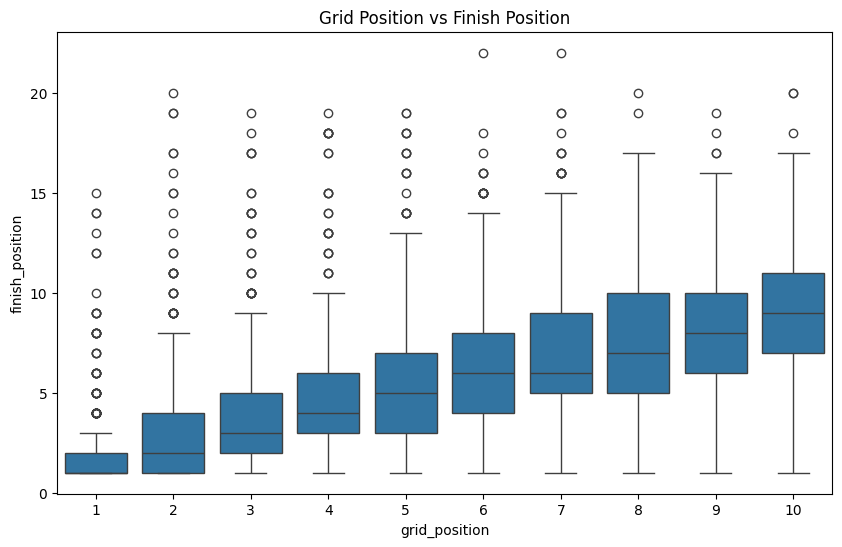

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x="grid_position", y="finish_position", data=df[df["grid_position"] <= 10])
plt.title("Grid Position vs Finish Position")
plt.show()

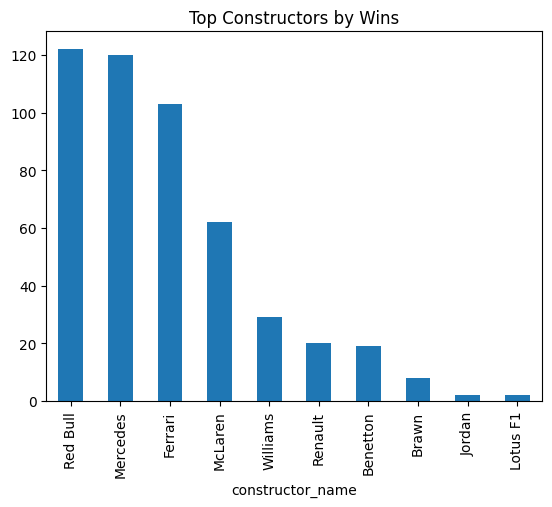

In [6]:
wins = df[df["finish_position"] == 1]

constructor_wins = wins["constructor_name"].value_counts().head(10)

constructor_wins.plot(kind="bar")
plt.title("Top Constructors by Wins")
plt.show()

In [7]:
df["is_winner"] = (df["finish_position"] == 1).astype(int)

df["is_podium"] = (df["finish_position"] <= 3).astype(int)

In [8]:
df.to_csv("../data/processed/eda_dataset.csv", index=False)